# 04 Model Comparison

Objective: evaluate two additional tree-based regressors for `ClosePrice` prediction and compare their final test R² against Linear Regression baseline.

Models in this notebook:
- Decision Tree Regressor
- Random Forest Regressor

This notebook intentionally reuses the Week 4 feature set, fixed 5-month training window, final test month, and training-only price outlier bounds so the comparison is apples-to-apples.

## 0. Setup

In [84]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
SPLIT_DIR = PROCESSED_DATA_DIR / "splits"
BASELINE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week4_baseline"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week5_model_comparison"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CURRENT_OUTPUT_FILENAMES = [
    "untuned_tree_model_test_results.csv",
    "test_predictions_tree_models_untuned.csv",
    "tuned_tree_model_test_results.csv",
    "test_predictions_tree_models_tuned.csv",
    "test_predictions_tree_models_all.csv",
    "tuning_cv_results.csv",
    "model_comparison_summary.csv",
    "baseline_vs_tuned_model_comparison_summary.csv",
    "random_forest_feature_importances.csv",
]
STALE_OUTPUT_FILENAMES = [
    "tree_model_test_results.csv",
    "test_predictions_tree_models.csv",
    "tree_error_by_price_band.csv",
    "tree_feature_importances.csv",
]

for filename in STALE_OUTPUT_FILENAMES:
    stale_path = OUTPUT_DIR / filename
    if stale_path.exists():
        stale_path.unlink()
        print(f"Removed stale output: {stale_path.relative_to(PROJECT_ROOT)}")

DECISION_TREE_PATH = MODEL_DIR / "decision_tree_pipeline.joblib"
RANDOM_FOREST_PATH = MODEL_DIR / "random_forest_pipeline.joblib"
TUNED_DECISION_TREE_PATH = MODEL_DIR / "decision_tree_tuned_pipeline.joblib"
TUNED_RANDOM_FOREST_PATH = MODEL_DIR / "random_forest_tuned_pipeline.joblib"

SPLIT_PLAN_CSV = PROCESSED_DATA_DIR / "crmls_week3_split_plan.csv"
FINAL_TRAIN_CSV = SPLIT_DIR / "final_train_fixed_window_cleaned.csv"
TEST_CSV = SPLIT_DIR / "test_latest_month_cleaned.csv"
BASELINE_RESULTS_CSV = BASELINE_OUTPUT_DIR / "final_test_results.csv"

RANDOM_STATE = 42

print(f"Split directory: {SPLIT_DIR}")
print(f"Baseline results: {BASELINE_RESULTS_CSV}")
print(f"Output directory: {OUTPUT_DIR}")

Split directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/splits
Baseline results: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week4_baseline/final_test_results.csv
Output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week5_model_comparison


## 1. Load Final Train/Test Split and Baseline Result

The final comparison uses the same production-style split from Week 4: train on `2025-12` through `2026-04`, then evaluate on `2026-05`.

In [85]:
def load_split_file(path):
    df = pd.read_csv(path, low_memory=False)
    if "CloseDate" in df.columns:
        df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
    if "close_month" in df.columns:
        df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")
    return df

split_plan = pd.read_csv(SPLIT_PLAN_CSV, dtype={"split_type": "string", "eval_month": "string"})
final_plan = split_plan[split_plan["split_type"] == "final_test"].copy().iloc[0]
fixed_train_window_months = int(final_plan["train_window_months"])

final_train_df_raw = load_split_file(FINAL_TRAIN_CSV)
test_df_raw = load_split_file(TEST_CSV)
baseline_results = pd.read_csv(BASELINE_RESULTS_CSV)

print(f"Raw final train shape: {final_train_df_raw.shape}")
print(f"Raw final test shape: {test_df_raw.shape}")
print(f"Final train months: {final_plan['train_months']}")
print(f"Final test month: {final_plan['eval_month']}")
display(baseline_results)

Raw final train shape: (49667, 45)
Raw final test shape: (12024, 45)
Final train months: 2025-12, 2026-01, 2026-02, 2026-03, 2026-04
Final test month: 2026-05


,model,target,train_window_months,final_train_month_start,final_train_month_end,final_train_months,test_month,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,train_r2,train_mae,test_r2,test_mae,test_rmse,test_mape,test_mdape,model_path
0,LinearRegression,ClosePrice,5,2025-12,2026-04,"2025-12, 2026-01, 2026-02, 2026-03, 2026-04",2026-05,185000.0,9250000.0,49667,49177,12024,11919,0.841152,227469.35435,0.83227,247176.786082,413890.359568,23.043397,16.049778,models/linear_regression_baseline_pipeline.joblib


## 2. Define Model Features and Preprocessing

The feature list mirrors `03_baseline_model.ipynb`. The only difference from the linear baseline preprocessing is that tree-based models do not need numeric scaling.

In [86]:
target = "ClosePrice"
metadata_cols = ["ListingKey", "CloseDate", "close_month", "source_file"]

continuous_numeric_cols = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee",
]
count_numeric_cols = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
]
numeric_cols = continuous_numeric_cols + count_numeric_cols
boolean_cols = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN"]
categorical_cols = ["City", "CountyOrParish", "PostalCode", "MLSAreaMajor", "Levels", "Flooring", "HighSchoolDistrict"]
flag_cols = [col for col in final_train_df_raw.columns if col.endswith("_missing") or col == "invalid_coordinates_flag"]

numeric_cols = [col for col in numeric_cols if col in final_train_df_raw.columns]
boolean_cols = [col for col in boolean_cols if col in final_train_df_raw.columns]
categorical_cols = [col for col in categorical_cols if col in final_train_df_raw.columns]
flag_cols = [col for col in flag_cols if col in final_train_df_raw.columns]
feature_cols = numeric_cols + categorical_cols + boolean_cols + flag_cols

feature_summary = pd.DataFrame({
    "feature_group": ["numeric", "categorical", "boolean", "missing_or_quality_flags", "total_raw_model_features"],
    "n_features": [len(numeric_cols), len(categorical_cols), len(boolean_cols), len(flag_cols), len(feature_cols)],
})
display(feature_summary)

,feature_group,n_features
0,numeric,11
1,categorical,7
2,boolean,5
3,missing_or_quality_flags,17
4,total_raw_model_features,40


In [87]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_preprocessing_pipeline(numeric_features, categorical_features, boolean_features, flag_features, scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(steps=numeric_steps)

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("onehot", make_onehot_encoder()),
    ])
    boolean_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))])
    flag_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0))])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
            ("bool", boolean_pipeline, boolean_features),
            ("flag", flag_pipeline, flag_features),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )


def build_model_pipeline(model, scale_numeric=True):
    preprocess = build_preprocessing_pipeline(
        numeric_cols,
        categorical_cols,
        boolean_cols,
        flag_cols,
        scale_numeric=scale_numeric,
    )

    return Pipeline([
        ("preprocess", preprocess),
        ("model", model),
    ])


## 3. Define Outlier and Evaluation Functions

Outlier bounds are learned from the training data only, then applied to the test month unchanged. This keeps the tree model comparison consistent with Week 4.

In [88]:
def apply_train_price_bounds(train_df, eval_df, target_col="ClosePrice", lower_q=0.005, upper_q=0.995):
    lower_bound = train_df[target_col].quantile(lower_q)
    upper_bound = train_df[target_col].quantile(upper_q)
    train_mask = train_df[target_col].between(lower_bound, upper_bound)
    eval_mask = eval_df[target_col].between(lower_bound, upper_bound)
    return (
        train_df.loc[train_mask].copy(),
        eval_df.loc[eval_mask].copy(),
        {
            "price_lower_bound": lower_bound,
            "price_upper_bound": upper_bound,
            "train_rows_before_outlier_filter": len(train_df),
            "train_rows_after_outlier_filter": int(train_mask.sum()),
            "eval_rows_before_outlier_filter": len(eval_df),
            "eval_rows_after_outlier_filter": int(eval_mask.sum()),
        },
    )


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    absolute_percentage_error = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": absolute_percentage_error.mean(),
        "mdape": absolute_percentage_error.median(),
    }


final_train_df, final_test_df, final_bound_info = apply_train_price_bounds(final_train_df_raw, test_df_raw)

print(f"Train rows after price filter: {len(final_train_df):,} of {len(final_train_df_raw):,}")
print(f"Test rows after price filter: {len(final_test_df):,} of {len(test_df_raw):,}")
print(f"Training-derived price bounds: ${final_bound_info['price_lower_bound']:,.0f} to ${final_bound_info['price_upper_bound']:,.0f}")

Train rows after price filter: 49,177 of 49,667
Test rows after price filter: 11,919 of 12,024
Training-derived price bounds: $185,000 to $9,250,000


## 4. Train Decision Tree and Random Forest

Start with untuned scikit-learn defaults so the first comparison has a clean reference point before parameter tuning.

These models intentionally use the estimator defaults:
- `DecisionTreeRegressor()`
- `RandomForestRegressor()`


In [89]:
model_specs = {
    "DecisionTreeRegressor_untuned": {
        "estimator": DecisionTreeRegressor(
            random_state=RANDOM_STATE
        ),
        "model_path": MODEL_DIR / "decision_tree_pipeline.joblib",
        "scale_numeric": False,
    },
    "RandomForestRegressor_untuned": {
        "estimator": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "model_path": MODEL_DIR / "random_forest_pipeline.joblib",
        "scale_numeric": False,
    },
}

model_results = []
fitted_models = {}
prediction_frames = []

for model_name, spec in model_specs.items():
    print(f"Training {model_name}...")
    pipeline = build_model_pipeline(spec["estimator"], scale_numeric=spec["scale_numeric"])
    pipeline.fit(final_train_df[feature_cols], final_train_df[target])

    train_predictions = pipeline.predict(final_train_df[feature_cols])
    test_predictions = pipeline.predict(final_test_df[feature_cols])
    train_metrics = regression_metrics(final_train_df[target], train_predictions)
    test_metrics = regression_metrics(final_test_df[target], test_predictions)

    joblib.dump({
        "model": pipeline,
        "feature_cols": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "boolean_cols": boolean_cols,
        "flag_cols": flag_cols,
        "target": target,
        "price_bounds": {
            "lower": final_bound_info["price_lower_bound"],
            "upper": final_bound_info["price_upper_bound"],
        },
        "train_months": final_plan["train_months"],
        "test_month": final_plan["eval_month"],
        "scale_numeric": spec["scale_numeric"],
        "estimator_params": pipeline.named_steps["model"].get_params(),
    }, spec["model_path"])

    model_results.append({
        "model": model_name,
        "target": target,
        "train_window_months": fixed_train_window_months,
        "final_train_month_start": final_plan["train_month_start"],
        "final_train_month_end": final_plan["train_month_end"],
        "final_train_months": final_plan["train_months"],
        "test_month": final_plan["eval_month"],
        **final_bound_info,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_mape": test_metrics["mape"],
        "test_mdape": test_metrics["mdape"],
        "model_path": str(spec["model_path"].relative_to(PROJECT_ROOT)),
    })

    pred_df = final_test_df[["ListingKey", "CloseDate", "close_month", "CountyOrParish", target]].copy()
    pred_df["model"] = model_name
    pred_df["predicted_ClosePrice"] = test_predictions
    pred_df["residual"] = pred_df[target] - pred_df["predicted_ClosePrice"]
    pred_df["absolute_error"] = pred_df["residual"].abs()
    pred_df["absolute_percentage_error"] = pred_df["absolute_error"] / pred_df[target] * 100
    prediction_frames.append(pred_df)
    fitted_models[model_name] = pipeline

model_results_df = pd.DataFrame(model_results)
model_results_df.to_csv(OUTPUT_DIR / "untuned_tree_model_test_results.csv", index=False)

all_predictions = pd.concat(prediction_frames, ignore_index=True)
all_predictions.to_csv(OUTPUT_DIR / "test_predictions_tree_models_untuned.csv", index=False)

untuned_model_summary = model_results_df[[
    "model",
    "train_r2",
    "test_r2",
    "train_mae",
    "test_mae",
    "test_rmse",
    "test_mdape",
]].copy()

display(untuned_model_summary)

Training DecisionTreeRegressor_untuned...
Training RandomForestRegressor_untuned...


,model,train_r2,test_r2,train_mae,test_mae,test_rmse,test_mdape
0,DecisionTreeRegressor_untuned,0.999993,0.725835,51.959500,260116.969765,529157.806267,12.222222
1,RandomForestRegressor_untuned,0.979503,0.857600,66315.636584,184570.515117,381359.587394,8.683491


## 5. Hyperparameter Tuning

Tune model parameters using only the final training window. The last training month is held out as a validation fold with `PredefinedSplit`; the final test month remains untouched until the final comparison.

- Decision Tree uses exhaustive `GridSearchCV` because the search space is small.
- Random Forest uses `RandomizedSearchCV` because a full grid over forest parameters would be much more expensive.


In [90]:
# Hold out the most recent training month for hyperparameter selection.
# Tuning outlier bounds are learned only from rows before the validation month.
tuning_validation_month = final_train_df_raw["close_month"].max()
tuning_train_raw = final_train_df_raw[final_train_df_raw["close_month"].lt(tuning_validation_month)].copy()
tuning_validation_raw = final_train_df_raw[final_train_df_raw["close_month"].eq(tuning_validation_month)].copy()
tuning_train_df, tuning_validation_df, tuning_bound_info = apply_train_price_bounds(
    tuning_train_raw,
    tuning_validation_raw,
)
tuning_df = pd.concat([tuning_train_df, tuning_validation_df], ignore_index=True)
tuning_fold = np.r_[
    np.full(len(tuning_train_df), -1),
    np.zeros(len(tuning_validation_df), dtype=int),
]
tuning_cv = PredefinedSplit(test_fold=tuning_fold)

print(f"Tuning validation month: {tuning_validation_month}")
print(f"Tuning-train rows after price filter: {len(tuning_train_df):,} of {len(tuning_train_raw):,}")
print(f"Validation rows after price filter: {len(tuning_validation_df):,} of {len(tuning_validation_raw):,}")
print(
    "Tuning price bounds learned from pre-validation rows: "
    f"${tuning_bound_info['price_lower_bound']:,.0f} to ${tuning_bound_info['price_upper_bound']:,.0f}"
)

tuning_specs = {
    "DecisionTreeRegressor_tuned": {
        "search": GridSearchCV(
            estimator=build_model_pipeline(
                DecisionTreeRegressor(random_state=RANDOM_STATE),
                scale_numeric=False,
            ),
            param_grid={
                "model__max_depth": [8, 12, 16, 20, 24, None],
                "model__min_samples_leaf": [1, 5, 10, 25, 50, 100],
                "model__min_samples_split": [2, 20, 50, 100, 200],
            },
            scoring="r2",
            cv=tuning_cv,
            n_jobs=-1,
            refit=False,
            verbose=1,
        ),
        "final_estimator": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "model_path": TUNED_DECISION_TREE_PATH,
        "scale_numeric": False,
        "search_type": "GridSearchCV",
    },
    "RandomForestRegressor_tuned": {
        "search": RandomizedSearchCV(
            estimator=build_model_pipeline(
                RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
                scale_numeric=False,
            ),
            param_distributions={
                "model__n_estimators": [100, 200, 300, 400],
                "model__max_depth": [None, 12, 18, 24, 30],
                "model__min_samples_leaf": [1, 3, 5, 10, 20],
                "model__min_samples_split": [2, 10, 25, 50],
                "model__max_features": [1.0, "sqrt", "log2", 0.4, 0.6, 0.8],
                "model__bootstrap": [True],
            },
            n_iter=24,
            scoring="r2",
            cv=tuning_cv,
            n_jobs=1,
            refit=False,
            random_state=RANDOM_STATE,
            verbose=1,
        ),
        "final_estimator": RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
        "model_path": TUNED_RANDOM_FOREST_PATH,
        "scale_numeric": False,
        "search_type": "RandomizedSearchCV",
    },
}

tuned_model_results = []
tuned_prediction_frames = []
tuning_cv_results = []

for model_name, spec in tuning_specs.items():
    print(f"Tuning {model_name}...")
    search = spec["search"]
    search.fit(tuning_df[feature_cols], tuning_df[target])

    tuned_pipeline = build_model_pipeline(spec["final_estimator"], scale_numeric=spec["scale_numeric"])
    tuned_pipeline.set_params(**search.best_params_)
    tuned_pipeline.fit(final_train_df[feature_cols], final_train_df[target])

    train_predictions = tuned_pipeline.predict(final_train_df[feature_cols])
    test_predictions = tuned_pipeline.predict(final_test_df[feature_cols])
    train_metrics = regression_metrics(final_train_df[target], train_predictions)
    test_metrics = regression_metrics(final_test_df[target], test_predictions)

    joblib.dump({
        "model": tuned_pipeline,
        "search": search,
        "feature_cols": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "boolean_cols": boolean_cols,
        "flag_cols": flag_cols,
        "target": target,
        "price_bounds": {
            "lower": final_bound_info["price_lower_bound"],
            "upper": final_bound_info["price_upper_bound"],
        },
        "tuning_price_bounds": {
            "lower": tuning_bound_info["price_lower_bound"],
            "upper": tuning_bound_info["price_upper_bound"],
        },
        "train_months": final_plan["train_months"],
        "test_month": final_plan["eval_month"],
        "tuning_validation_month": str(tuning_validation_month),
        "best_params": search.best_params_,
        "best_validation_r2": search.best_score_,
        "random_state": RANDOM_STATE,
        "scale_numeric": spec["scale_numeric"],
        "search_type": spec["search_type"],
    }, spec["model_path"])

    tuned_model_results.append({
        "model": model_name,
        "target": target,
        "train_window_months": fixed_train_window_months,
        "final_train_month_start": final_plan["train_month_start"],
        "final_train_month_end": final_plan["train_month_end"],
        "final_train_months": final_plan["train_months"],
        "test_month": final_plan["eval_month"],
        **final_bound_info,
        "tuning_price_lower_bound": tuning_bound_info["price_lower_bound"],
        "tuning_price_upper_bound": tuning_bound_info["price_upper_bound"],
        "tuning_train_rows_after_outlier_filter": len(tuning_train_df),
        "tuning_validation_rows_after_outlier_filter": len(tuning_validation_df),
        "search_type": spec["search_type"],
        "tuning_validation_month": str(tuning_validation_month),
        "best_validation_r2": search.best_score_,
        "best_params": search.best_params_,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_mape": test_metrics["mape"],
        "test_mdape": test_metrics["mdape"],
        "model_path": str(spec["model_path"].relative_to(PROJECT_ROOT)),
    })

    pred_df = final_test_df[["ListingKey", "CloseDate", "close_month", "CountyOrParish", target]].copy()
    pred_df["model"] = model_name
    pred_df["predicted_ClosePrice"] = test_predictions
    pred_df["residual"] = pred_df[target] - pred_df["predicted_ClosePrice"]
    pred_df["absolute_error"] = pred_df["residual"].abs()
    pred_df["absolute_percentage_error"] = pred_df["absolute_error"] / pred_df[target] * 100
    tuned_prediction_frames.append(pred_df)
    fitted_models[model_name] = tuned_pipeline

    cv_results_df = pd.DataFrame(search.cv_results_).assign(model=model_name)
    tuning_cv_results.append(cv_results_df)


tuned_model_results_df = pd.DataFrame(tuned_model_results)
tuned_model_results_df.to_csv(OUTPUT_DIR / "tuned_tree_model_test_results.csv", index=False)

if tuned_prediction_frames:
    tuned_predictions = pd.concat(tuned_prediction_frames, ignore_index=True)
    tuned_predictions.to_csv(OUTPUT_DIR / "test_predictions_tree_models_tuned.csv", index=False)
    all_predictions = pd.concat([all_predictions, tuned_predictions], ignore_index=True)
    all_predictions.to_csv(OUTPUT_DIR / "test_predictions_tree_models_all.csv", index=False)

if tuning_cv_results:
    tuning_cv_results_df = pd.concat(tuning_cv_results, ignore_index=True)
    tuning_cv_results_df.to_csv(OUTPUT_DIR / "tuning_cv_results.csv", index=False)

tuned_model_order = ["DecisionTreeRegressor_tuned", "RandomForestRegressor_tuned"]
best_param_summary = tuned_model_results_df[[
    "model",
    "best_validation_r2",
    "train_r2",
    "test_r2",
    "train_mae",
    "test_mae",
    "test_rmse",
    "test_mdape",
]].copy()
best_param_summary["model"] = pd.Categorical(
    best_param_summary["model"],
    categories=tuned_model_order,
    ordered=True,
)
best_param_summary = best_param_summary.sort_values("model").reset_index(drop=True)
best_param_summary["model"] = best_param_summary["model"].astype(str)

display(best_param_summary)

print("Best hyperparameters:")
for _, row in tuned_model_results_df.sort_values("model").iterrows():
    print(f"{row['model']}:")
    for param_name, param_value in row["best_params"].items():
        print(f"  {param_name}: {param_value}")
    print(f"  validation R²: {row['best_validation_r2']:.4f}")


Tuning validation month: 2026-04
Tuning-train rows after price filter: 37,265 of 37,642
Validation rows after price filter: 11,914 of 12,025
Tuning price bounds learned from pre-validation rows: $179,205 to $9,150,000
Tuning DecisionTreeRegressor_tuned...
Fitting 1 folds for each of 180 candidates, totalling 180 fits
Tuning RandomForestRegressor_tuned...
Fitting 1 folds for each of 24 candidates, totalling 24 fits


,model,best_validation_r2,train_r2,test_r2,train_mae,test_mae,test_rmse,test_mdape
0,DecisionTreeRegressor_tuned,0.764681,0.874507,0.765362,179723.494707,244936.615307,489529.316840,11.769034
1,RandomForestRegressor_tuned,0.844353,0.955166,0.854532,102005.523960,186389.829257,385446.331327,8.628325


Best hyperparameters:
DecisionTreeRegressor_tuned:
  model__max_depth: 24
  model__min_samples_leaf: 1
  model__min_samples_split: 50
  validation R²: 0.7647
RandomForestRegressor_tuned:
  model__n_estimators: 100
  model__min_samples_split: 10
  model__min_samples_leaf: 1
  model__max_features: 0.8
  model__max_depth: 30
  model__bootstrap: True
  validation R²: 0.8444


## 6. Compare Test R² Against Baseline

In [91]:
baseline_compare_cols = [
    "model",
    "train_r2",
    "train_mae",
    "test_r2",
    "test_mae",
    "test_rmse",
    "test_mape",
    "test_mdape",
]

tree_compare_cols = baseline_compare_cols + ["search_type", "best_validation_r2", "best_params"]
model_order = [
    "LinearRegression",
    "DecisionTreeRegressor_untuned",
    "RandomForestRegressor_untuned",
    "DecisionTreeRegressor_tuned",
    "RandomForestRegressor_tuned",
]

comparison_parts = [
    baseline_results[baseline_compare_cols].assign(
        model_family="baseline",
        search_type="not_tuned",
        best_validation_r2=np.nan,
        best_params=np.nan,
    ),
    model_results_df[baseline_compare_cols].assign(
        model_family="tree_based_untuned",
        search_type="sklearn_default",
        best_validation_r2=np.nan,
        best_params=np.nan,
    ),
]

if "tuned_model_results_df" in globals() and not tuned_model_results_df.empty:
    comparison_parts.append(
        tuned_model_results_df[tree_compare_cols].assign(model_family="tree_based_tuned")
    )

comparison_df = pd.concat(comparison_parts, ignore_index=True)

baseline_test_r2 = baseline_results.loc[baseline_results["model"].eq("LinearRegression"), "test_r2"].iloc[0]
baseline_test_mae = baseline_results.loc[baseline_results["model"].eq("LinearRegression"), "test_mae"].iloc[0]
comparison_df["test_r2_delta_vs_baseline"] = comparison_df["test_r2"] - baseline_test_r2
comparison_df["test_mae_delta_vs_baseline"] = comparison_df["test_mae"] - baseline_test_mae
comparison_df["model"] = pd.Categorical(comparison_df["model"], categories=model_order, ordered=True)
comparison_df = comparison_df.sort_values("model").reset_index(drop=True)
comparison_df["model"] = comparison_df["model"].astype(str)
model_order_present = [model for model in model_order if model in comparison_df["model"].tolist()]
comparison_display_df = comparison_df[~comparison_df["model"].str.endswith("_untuned")].copy()
comparison_display_order = [model for model in model_order if model in comparison_display_df["model"].tolist()]

comparison_df.to_csv(OUTPUT_DIR / "model_comparison_summary.csv", index=False)
comparison_display_df.to_csv(OUTPUT_DIR / "baseline_vs_tuned_model_comparison_summary.csv", index=False)
display(comparison_display_df.round(4))

best_model = comparison_display_df.loc[comparison_display_df["test_r2"].idxmax()]
print(f"Best baseline/tuned model by final test R²: {best_model['model']} ({best_model['test_r2']:.4f})")
print(f"Baseline test R²: {baseline_test_r2:.4f}")


,model,train_r2,train_mae,test_r2,test_mae,test_rmse,test_mape,test_mdape,model_family,search_type,best_validation_r2,best_params,test_r2_delta_vs_baseline,test_mae_delta_vs_baseline
0,LinearRegression,0.8412,227469.3544,0.8323,247176.7861,413890.3596,23.0434,16.0498,baseline,not_tuned,NaN,NaN,0.0000,0.0000
3,DecisionTreeRegressor_tuned,0.8745,179723.4947,0.7654,244936.6153,489529.3168,17.9165,11.7690,tree_based_tuned,GridSearchCV,0.7647,"{'model__max_depth': 24, 'model__min_samples_l...",-0.0669,-2240.1708
4,RandomForestRegressor_tuned,0.9552,102005.5240,0.8545,186389.8293,385446.3313,13.4989,8.6283,tree_based_tuned,RandomizedSearchCV,0.8444,"{'model__n_estimators': 100, 'model__min_sampl...",0.0223,-60786.9568


Best baseline/tuned model by final test R²: RandomForestRegressor_tuned (0.8545)
Baseline test R²: 0.8323


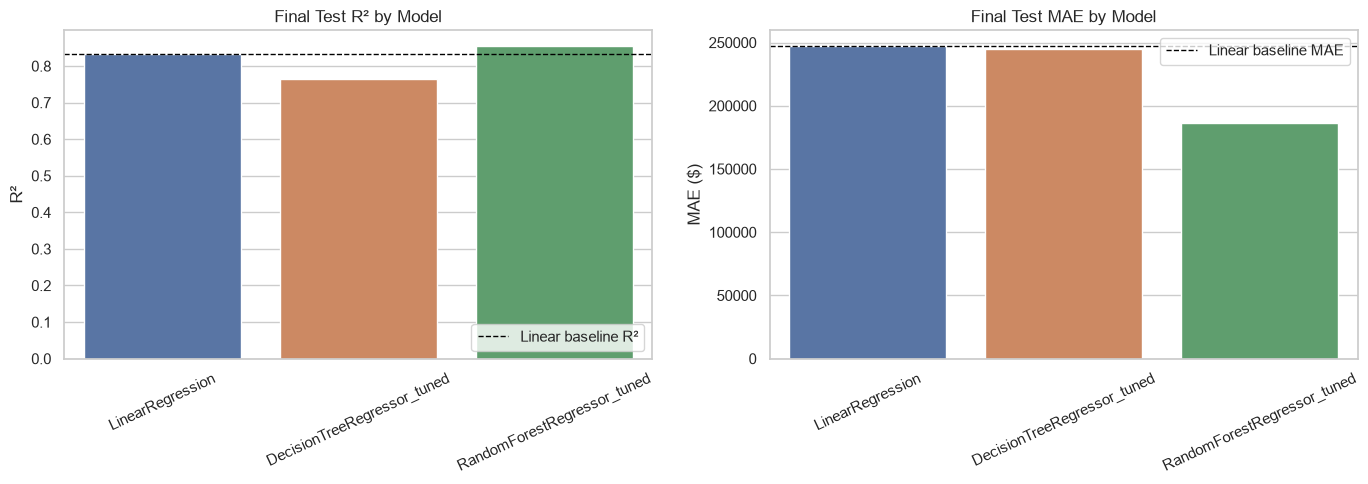

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=comparison_display_df,
    x="model",
    y="test_r2",
    hue="model",
    order=comparison_display_order,
    dodge=False,
    ax=axes[0],
)
axes[0].axhline(baseline_test_r2, color="black", linestyle="--", linewidth=1, label="Linear baseline R²")
axes[0].set_title("Final Test R² by Model")
axes[0].set_xlabel("")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(loc="lower right")

sns.barplot(
    data=comparison_display_df,
    x="model",
    y="test_mae",
    hue="model",
    order=comparison_display_order,
    dodge=False,
    ax=axes[1],
)
axes[1].axhline(baseline_test_mae, color="black", linestyle="--", linewidth=1, label="Linear baseline MAE")
axes[1].set_title("Final Test MAE by Model")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE ($)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 7. Model Behavior Diagnostics

Keep this section focused on two model-behavior checks:
- Train vs. Test R² by model to inspect generalization gaps.
- Random Forest feature importance to summarize the strongest predictors used by the forest.

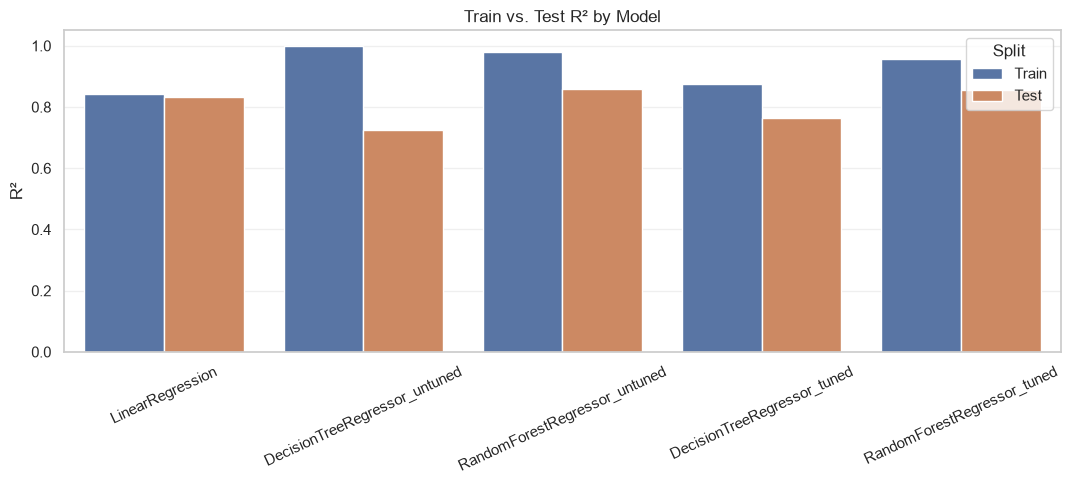

In [93]:
r2_plot_df = comparison_df[["model", "model_family", "train_r2", "test_r2"]].melt(
    id_vars=["model", "model_family"],
    value_vars=["train_r2", "test_r2"],
    var_name="split",
    value_name="r2",
)
r2_plot_df["split"] = r2_plot_df["split"].map({"train_r2": "Train", "test_r2": "Test"})

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=r2_plot_df,
    x="model",
    y="r2",
    hue="split",
    order=model_order_present,
    ax=ax,
)
ax.set_title("Train vs. Test R² by Model")
ax.set_xlabel("")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Split")

plt.tight_layout()
plt.show()


,model,feature,importance
0,RandomForestRegressor_tuned,num__LivingArea,0.257609
1,RandomForestRegressor_tuned,num__BathroomsTotalInteger,0.188288
2,RandomForestRegressor_tuned,num__Latitude,0.113858
3,RandomForestRegressor_tuned,num__Longitude,0.104331
4,RandomForestRegressor_tuned,flag__PoolPrivateYN_missing,0.041642
5,RandomForestRegressor_tuned,num__YearBuilt,0.026911
6,RandomForestRegressor_tuned,num__LotSizeSquareFeet,0.022152
7,RandomForestRegressor_tuned,cat__HighSchoolDistrict_Newport Mesa Unified,0.018729
8,RandomForestRegressor_tuned,flag__AssociationFee_missing,0.015387
9,RandomForestRegressor_tuned,cat__CountyOrParish_Orange,0.014751


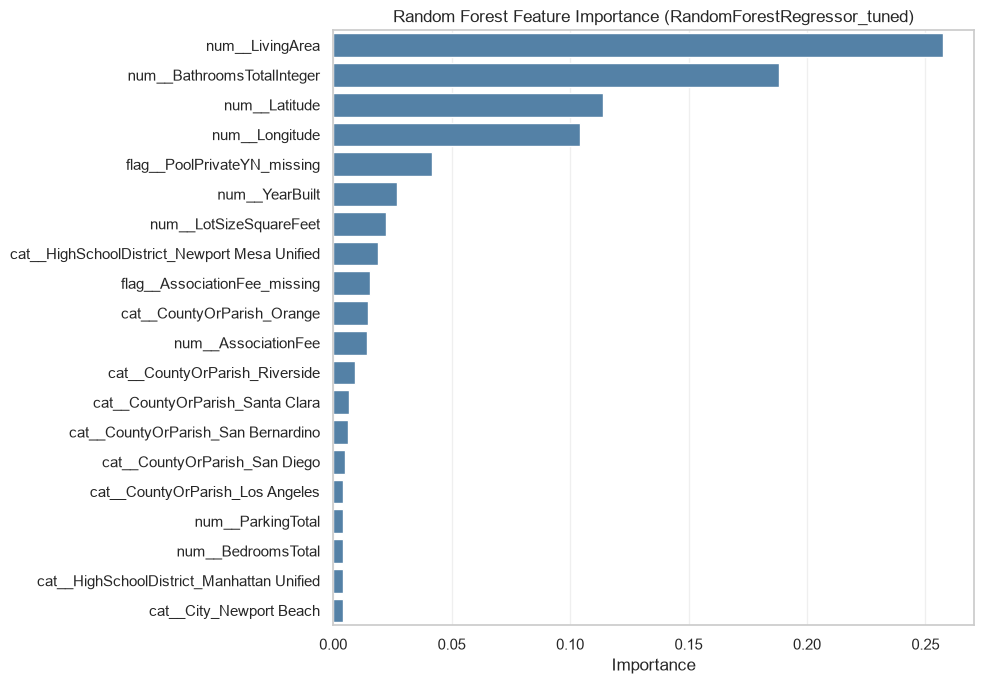

In [94]:
def get_feature_names(preprocessor):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        n_features = preprocessor.transform(final_train_df[feature_cols].head(1)).shape[1]
        return np.array([f"feature_{i}" for i in range(n_features)])


random_forest_model_names = [
    name for name in fitted_models
    if name.startswith("RandomForestRegressor")
]

if not random_forest_model_names:
    raise ValueError("No fitted Random Forest model is available for feature importance.")

# Prefer the tuned forest when the tuning cell has been run; otherwise use the untuned forest.
rf_model_name = "RandomForestRegressor_tuned" if "RandomForestRegressor_tuned" in fitted_models else random_forest_model_names[0]
rf_pipeline = fitted_models[rf_model_name]
rf_model = rf_pipeline.named_steps["model"]

feature_importance_df = (
    pd.DataFrame({
        "model": rf_model_name,
        "feature": get_feature_names(rf_pipeline.named_steps["preprocess"]),
        "importance": rf_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance_df.to_csv(OUTPUT_DIR / "random_forest_feature_importances.csv", index=False)

top_rf_importance = feature_importance_df.head(20)
display(top_rf_importance)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_rf_importance, y="feature", x="importance", ax=ax, color="steelblue")
ax.set_title(f"Random Forest Feature Importance ({rf_model_name})")
ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Behavior Notes

The untuned Decision Tree strongly overfit the training data, achieving a
training R² of 1.0000 but only 0.7228 on the test set. Hyperparameter tuning
reduced the train-test gap and improved test R² to 0.7754, but the tuned tree
still underperformed the Linear Regression baseline.

Random Forest performed substantially better than a single Decision Tree.
The untuned Random Forest achieved the highest observed final test R² of
0.8570, compared with 0.8323 for Linear Regression. The tuned Random Forest
reduced the train-test gap, but its test R² decreased slightly to 0.8545.
Therefore, tuning improved regularization but did not produce a meaningful
improvement in final R².

Overall, Random Forest captured nonlinear relationships and feature
interactions more effectively than Linear Regression and Decision Tree.
However, it required more computation and remained less interpretable than
the baseline model.


## 9. Summary

In [95]:
summary = comparison_df[[
    "model",
    "model_family",
    "search_type",
    "best_validation_r2",
    "train_r2",
    "test_r2",
    "test_r2_delta_vs_baseline",
    "test_mae",
    "test_mae_delta_vs_baseline",
    "test_mdape",
]].copy()
summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)
summary["model"] = summary["model"].astype(str)

display(summary.round(4))

created_output_files = [OUTPUT_DIR / filename for filename in CURRENT_OUTPUT_FILENAMES]

print(f"Saved comparison outputs to: {OUTPUT_DIR}")
print("Files created by this notebook:")
for path in created_output_files:
    if path.exists():
        print(f"- {path.relative_to(PROJECT_ROOT)}")


,model,model_family,search_type,best_validation_r2,train_r2,test_r2,test_r2_delta_vs_baseline,test_mae,test_mae_delta_vs_baseline,test_mdape
0,LinearRegression,baseline,not_tuned,NaN,0.8412,0.8323,0.0000,247176.7861,0.0000,16.0498
1,DecisionTreeRegressor_untuned,tree_based_untuned,sklearn_default,NaN,1.0000,0.7258,-0.1064,260116.9698,12940.1837,12.2222
2,RandomForestRegressor_untuned,tree_based_untuned,sklearn_default,NaN,0.9795,0.8576,0.0253,184570.5151,-62606.2710,8.6835
3,DecisionTreeRegressor_tuned,tree_based_tuned,GridSearchCV,0.7647,0.8745,0.7654,-0.0669,244936.6153,-2240.1708,11.7690
4,RandomForestRegressor_tuned,tree_based_tuned,RandomizedSearchCV,0.8444,0.9552,0.8545,0.0223,186389.8293,-60786.9568,8.6283


Saved comparison outputs to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week5_model_comparison
Files created by this notebook:
- outputs/week5_model_comparison/untuned_tree_model_test_results.csv
- outputs/week5_model_comparison/test_predictions_tree_models_untuned.csv
- outputs/week5_model_comparison/tuned_tree_model_test_results.csv
- outputs/week5_model_comparison/test_predictions_tree_models_tuned.csv
- outputs/week5_model_comparison/test_predictions_tree_models_all.csv
- outputs/week5_model_comparison/tuning_cv_results.csv
- outputs/week5_model_comparison/model_comparison_summary.csv
- outputs/week5_model_comparison/baseline_vs_tuned_model_comparison_summary.csv
- outputs/week5_model_comparison/random_forest_feature_importances.csv
